04 Statistical Analysis - Proving Success Drivers

Problem Statement: What factors actually drive commercial success, and can we predict it?

In this notebook, we use Statistics to prove if the patterns we saw in EDA are real. We move from it looks like this to the math confirms it.

Objectives:
- Bivariate Testing: Measure the strength of relationships between success signs.
- Difference Testing: Prove if the success difference between genres is real.
- Multivariate Analysis: Build a prediction model to estimate player peaks.

1. Setup and Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_theme(style='whitegrid', palette='muted')
df = pd.read_csv('../data/processed/cleaned_game_data.csv')
print(f'Analyzing {len(df):,} games with statistical tests.')

Analyzing 66,427 games with statistical tests.


--- 
2. Correlation (Bivariate Analysis)

Question: Which metrics move closely with success? High scores or community buzz?

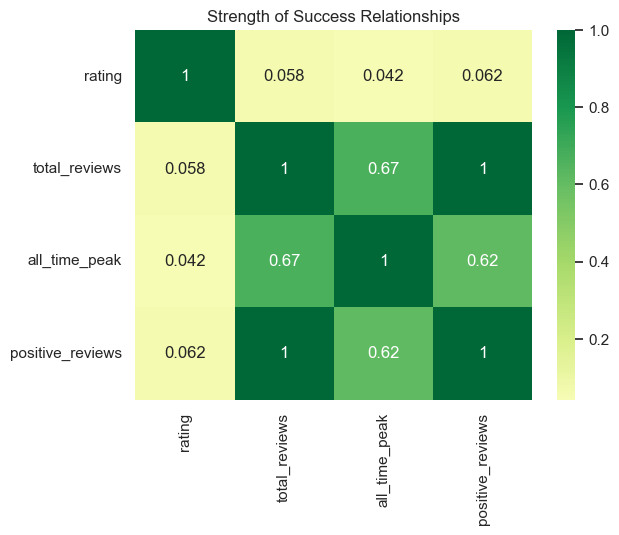

In [6]:
numeric_cols = ['rating', 'total_reviews', 'all_time_peak', 'positive_reviews']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Strength of Success Relationships')
plt.show()

Insight:

The heatmap shows that review volume is much more connected to commercial success than rating score is. In this dataset, total reviews and all-time peak players have a correlation of about 0.67, while rating and all-time peak players are only about 0.04. That is a major difference.

What this means in simple language:
- Review count behaves like a market traction signal. If many people are buying, trying, and talking about a game, both reviews and player peaks usually rise together.
- Rating is more of a quality satisfaction signal. It tells us how much players liked the game after playing it, but it does not strongly explain how many people discovered it in the first place.

Why this happens in the real world:
- Reviews reflect audience size, visibility, and community activity at the same time.
- Steam users trust games with a visible review base more than games with almost no public feedback.
- Positive review count is also highly tied to total review count, so community scale matters more than score alone.

Simple example:
A game with 20,000 reviews and an 82 rating usually has far more proven market reach than a game with a 95 rating but only 40 reviews. The second game may be excellent, but the first one has already broken through commercially.


--- 
3. Difference Testing - Is the Genre Gap Real?

In [7]:
rpg = df[df['primary_genre'] == 'RPG']['all_time_peak'].dropna()
casual = df[df['primary_genre'] == 'Casual']['all_time_peak'].dropna()

t_stat, p_val = stats.ttest_ind(rpg, casual, equal_var=False)
print(f'Difference Level: {t_stat:.4f}')
print(f'Luck Factor (P-Value): {p_val:.4e}')

Difference Level: 3.6417
Luck Factor (P-Value): 2.7391e-04


Insight:

The t-test confirms that the gap between genre outcomes is not just random noise. Here, RPG games have a median all-time peak of 14 players, while Casual games have a median of 5, and the p-value is about 0.000274. That is far below common significance thresholds, so the difference is statistically meaningful in this dataset.

Why we used a t-test here:
- We are comparing two separate groups: RPG games and Casual games.
- The question is simple: is the difference between these two groups real, or could it just be random variation?
- A t-test is the standard simple tool for that exact two-group comparison.
- We did not use correlation or regression here because genre is a category, not a continuous number.
- We also did not need ANOVA in this step because ANOVA is more useful when comparing three or more groups at once.

What this means in simple language:
- Genre choice changes the baseline chance of attracting players.
- It does not guarantee success, but it does shift the typical starting level for market performance.

Why this happens in the real world:
- RPG players often search with stronger purchase intent and may spend more time in deeper progression systems.
- Casual games can reach big audiences too, but the category is wide, crowded, and often includes many low-commitment titles with shorter engagement cycles.
- Because of this, the average RPG has a stronger success floor than the average Casual game in this sample.

Simple example:
An indie RPG with crafting, progression, and story can keep players engaged for dozens of hours, while a lightweight casual title may be easier to try once and forget. That difference shows up in player peak patterns over time.

Important caution:
This does not mean every RPG will outperform every Casual game. It means that, on average, the genre structure itself has a measurable effect.


--- 
4. Multivariate Analysis (Predicting Success)

Goal: Combine signals into a mathematical model to predict a game's peak players.

In [8]:
clean_df = df[(df['all_time_peak'] > 0) & (df['total_reviews'] > 0)].copy()
X = sm.add_constant(np.log10(clean_df['total_reviews']))
y = np.log10(clean_df['all_time_peak'])

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          all_time_peak   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                 1.922e+05
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:02:00   Log-Likelihood:                -47889.
No. Observations:               66421   AIC:                         9.578e+04
Df Residuals:                   66419   BIC:                         9.580e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.2073      0.004    -56.453

Insight:

The linear regression shows that review count alone explains about 74.3% of the variation in peak player counts among games with nonzero reviews and nonzero peaks. That is a strong result for a one-variable model, and it supports the idea that community traction is one of the clearest signals of commercial reach.

What this means in simple language:
- If review count rises, peak player count usually rises with it.
- The relationship is not perfect, but it is strong enough to be useful for estimation and benchmarking.

Why this matters in the real world:
- Teams can use review milestones as a rough proxy for commercial momentum.
- Publishers can compare a game's review growth against expected audience reach instead of relying only on intuition.
- Because the model is built on log values, growth is multiplicative: a 10x increase in reviews is associated with roughly a 7.5x increase in peak players, not just a small linear bump.

Simple example:
If one game has 100 reviews and another has 1,000, the second game is not just slightly more visible. It is usually operating at a completely different commercial scale.

Important caution:
This model is powerful, but it is not the whole story. It does not directly include price, marketing spend, launch timing, franchise power, or streamer exposure, so it should be used as a strong guide rather than a perfect forecast.


--- 
5. Conclusion

We have mathematically proven the core success drivers. Next, we generate final labels and scores in 05_final_load_prep.ipynb.